(custom_tsmodels)=

# Custom Time Series Models

In this tutorial, we will discuss how to customize your own time series models in ``FanInSAR``.

In [9]:
from faninsar.timeseries import TimeSeriesModels
import numpy as np
import pandas as pd
from typing import Sequence, Literal
from datetime import datetime
import matplotlib.pyplot as plt

## Creating a Custom Model

To create a custom model, you need to inherit from the `TimeSeriesModels` class. This class is an abstract base class that provides the fundamental framework for time series models. You are required to implement the `__init__` method to define model parameters and initialize its state.

For simple mathematical models, it is usually sufficient to specify the observation times (`dates`) and the time unit (`unit`). For more complex models, additional parameters may be needed to support the time series modeling.

As an example, we will create a simple cubic deformation time series model. The surface deformation {math}`d(t)` is mathematically expressed as:

```{math}
d(t) = a t^3 + b t^2 + c t + d
```

Here, `a`, `b`, `c`, and `d` are model parameters estimated from NSBAS inversion, and `t` represents time.

In [2]:
class CubicModel(TimeSeriesModels):
    """Cubic model."""

    def __init__(
        self,
        dates: pd.DatetimeIndex | Sequence[datetime],
        unit: Literal["year", "day"] = "day",
    ) -> None:
        """Initialize CubicModel.

        Parameters
        ----------
        dates : pd.DatetimeIndex | Sequence[datetime]
            Dates of SAR acquisitions. This can be easily obtained by accessing
            :attr:`Pairs.dates <faninsar.Pairs.dates>`.
        unit : Literal["year", "day"], optional
            Unit of day spans in time series model, by default "day".

        """
        super().__init__(dates, unit=unit)
        self._G_br = np.array(
            [
                self.date_spans**3,
                self.date_spans**2,
                self.date_spans,
                np.ones_like(self.date_spans),
            ],
        ).T
        self._param_names = ["Rate of Change", "acceleration", "velocity", "constant"]


1. `super().__init__(dates, unit=unit)` is used to pass initialization arguments to the parent class `TimeSeriesModels`. This automatically processes the time series dates and unit, and creates the `dates`, `unit`, and `date_spans` attributes necessary for model construction.

2. `date_spans` is computed from `dates` and `unit`, representing the time span of each date relative to the first date in the series. For simple mathematical models, it is usually sufficient to operate directly on `date_spans`.

3. `self._G_br` is used to generate the bottom-right portion of the NSBAS inversion matrix $G$, which in this case is the matrix $[t^3, t^2, t, 1]$.

4. `self._param_names` stores the names of the model parameters. We define them as `["Rate of Change", "Acceleration", "Velocity", "Constant"]`, corresponding to the four coefficients of the cubic model.

## Initializing the Model

In [6]:
dates = pd.date_range("2020-01-01", "2020-12-31", freq="12D")

cubic_model = CubicModel(dates, unit="year")

The model can then be passed to the [NSBASSolver](#faninsar.timeseries.solver.NSBASSolver) class, which is responsible for constructing the design matrix $\mathbf{G}$ and data vector $\mathbf{d}$ used in the NSBAS inversion. For detailed instructions on how to use the `NSBASSolver` class, refer to the [Operate NSBAS inversion](https://faninsar.readthedocs.io/en/latest/user_guide/quick_start.html#operate-nsbas-inversion) section of the quick start guide.

The bottom-right portion of the NSBAS inversion matrix $\mathbf{G}$ can be accessed via the `G_br` method, while the corresponding parameter names are available through the `param_names` method. 

In [16]:
names = cubic_model.param_names
print(names)

['Rate of Change', 'acceleration', 'velocity', 'constant']


In [7]:
print(cubic_model.G_br)

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00]
 [3.54628034e-05 1.07939908e-03 3.28542094e-02 1.00000000e+00]
 [2.83702427e-04 4.31759631e-03 6.57084189e-02 1.00000000e+00]
 [9.57495692e-04 9.71459170e-03 9.85626283e-02 1.00000000e+00]
 [2.26961942e-03 1.72703853e-02 1.31416838e-01 1.00000000e+00]
 [4.43285042e-03 2.69849770e-02 1.64271047e-01 1.00000000e+00]
 [7.65996553e-03 3.88583668e-02 1.97125257e-01 1.00000000e+00]
 [1.21637416e-02 5.28905548e-02 2.29979466e-01 1.00000000e+00]
 [1.81569553e-02 6.90815410e-02 2.62833676e-01 1.00000000e+00]
 [2.58523837e-02 8.74313253e-02 2.95687885e-01 1.00000000e+00]
 [3.54628034e-02 1.07939908e-01 3.28542094e-01 1.00000000e+00]
 [4.72009913e-02 1.30607288e-01 3.61396304e-01 1.00000000e+00]
 [6.12797243e-02 1.55433467e-01 3.94250513e-01 1.00000000e+00]
 [7.79117791e-02 1.82418444e-01 4.27104723e-01 1.00000000e+00]
 [9.73099325e-02 2.11562219e-01 4.59958932e-01 1.00000000e+00]
 [1.19686961e-01 2.42864793e-01 4.92813142e-01 1.000000

## Plotting model deformation

If we get the model parameters $\mathbf{m}$ after the NSBAS inversion, we can easily calculate the model deformation $d(t)$ using the $\mathbf{m}$ vector and the `G_br` matrix. 

In [30]:
m = np.array([4, 3, 2, 1])
d = cubic_model.G_br @ m

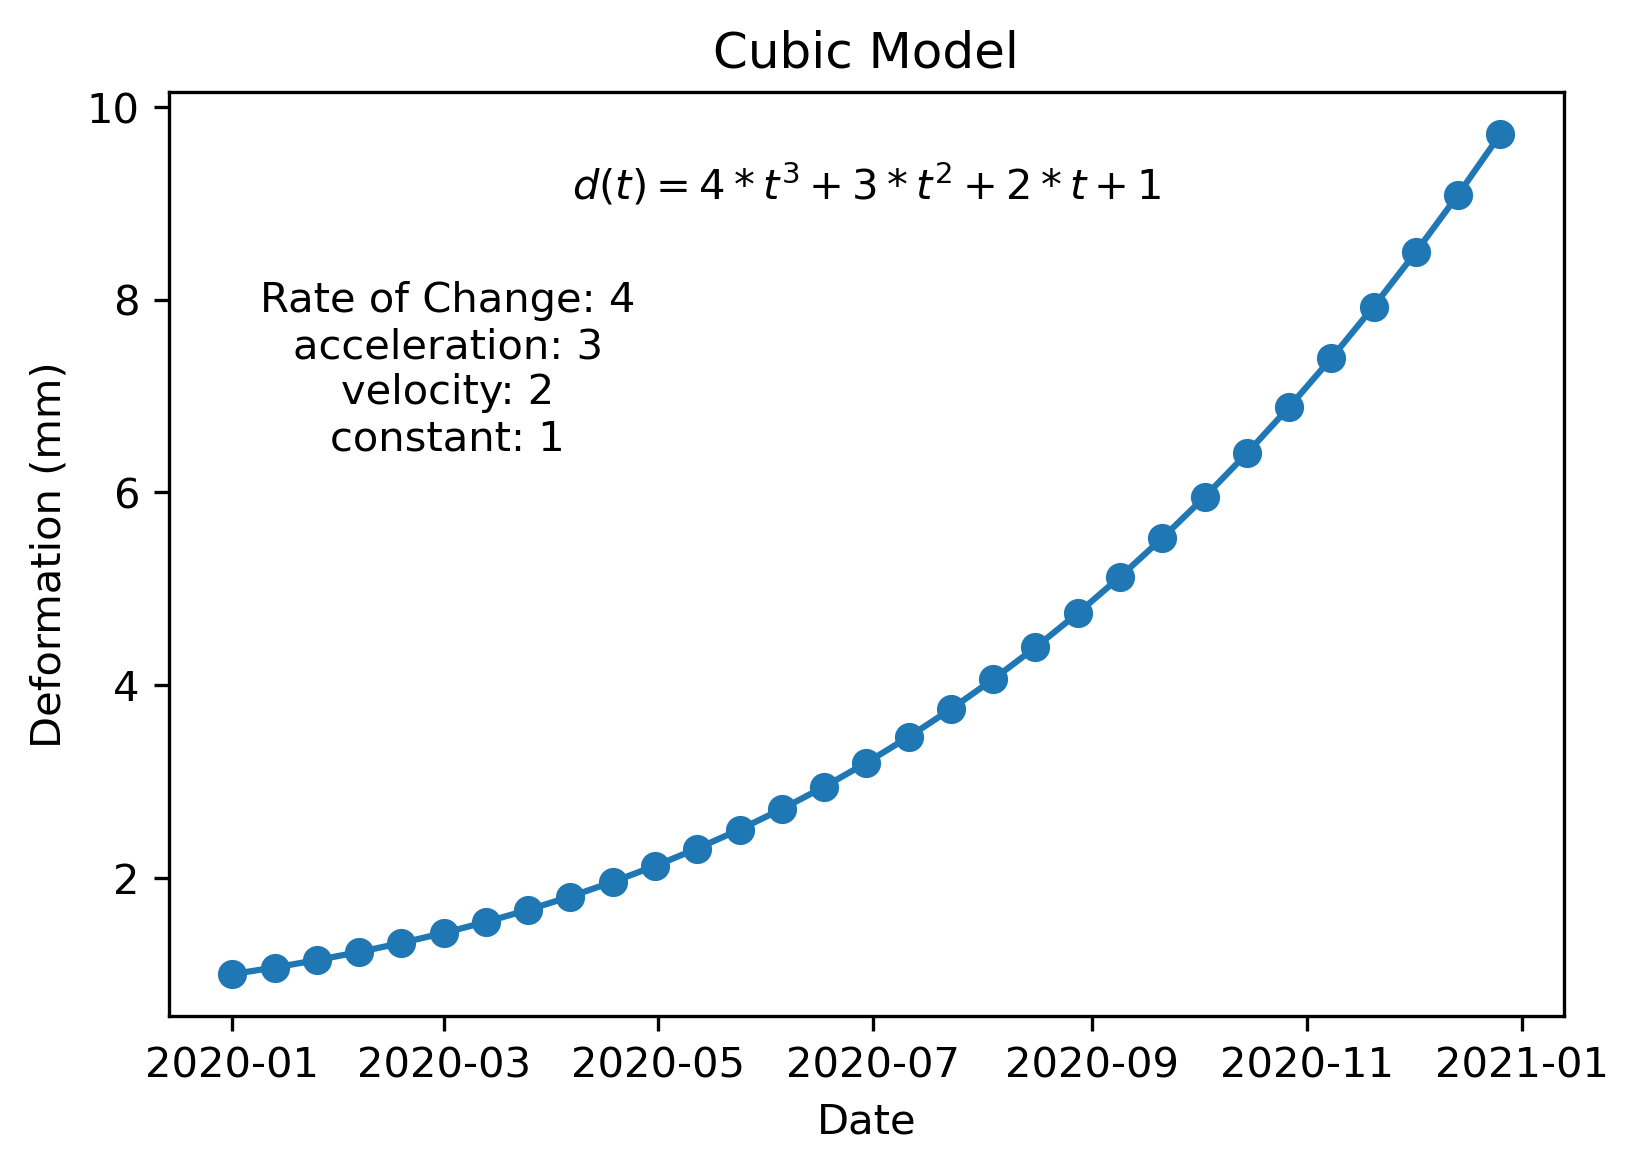

In [45]:
plt.figure(figsize=(6, 4), dpi=300)
plt.plot(cubic_model.dates, d, "o-")
plt.text(
    0.2,
    0.7,
    f"{names[0]}: {m[0]}\n{names[1]}: {m[1]}\n{names[2]}: {m[2]}\n{names[3]}: {m[3]}",
    ha="center",
    va="center",
    transform=plt.gca().transAxes,
)
plt.text(
    0.5,
    0.9,
    f"$d(t) = {m[0]} * t^3 + {m[1]} * t^2 + {m[2]} * t + {m[3]}$",
    ha="center",
    va="center",
    transform=plt.gca().transAxes,
)
plt.xlabel("Date")
plt.ylabel("Deformation (mm)")
plt.title("Cubic Model")
plt.show()